In [ ]:

import sys, os
sys.path.append(os.path.abspath("./drive/MyDrive/FYP"))

In [ ]:
import os
os.listdir("./drive/MyDrive/FYP")


['Quantization',
 'Knowledge graph extraction',
 '.ipynb_checkpoints',
 'Datasets',
 '.git']

In [ ]:
sys.path


['/content',
 '/env/python',
 '/usr/lib/python312.zip',
 '/usr/lib/python3.12',
 '/usr/lib/python3.12/lib-dynload',
 '',
 '/usr/local/lib/python3.12/dist-packages',
 '/usr/lib/python3/dist-packages',
 '/usr/local/lib/python3.12/dist-packages/IPython/extensions',
 '/root/.ipython',
 '/content/drive/MyDrive/FYP']

In [1]:
import torch.nn.functional as F

In [2]:
import torch
import torch.nn as nn
import math
from transformers.models.llama.modeling_llama import (
    apply_rotary_pos_emb,
    repeat_kv
)


In [3]:
class QuantLinear(nn.Module):
    def __init__(self, linear: nn.Linear, n_bits=8,act_quant=True):
        super().__init__()
        self.weight = linear.weight
        self.bias = linear.bias
        self.n_bits = n_bits
        self.act_quant = act_quant

        # Symmetric quant range
        self.qmax = 2 ** (n_bits - 1) - 1

        #Static weight scale (computed once)
        w_absmax = self.weight.abs().max()
        self.scale_w = w_absmax / self.qmax if w_absmax > 0 else 1.0

    def fake_quant(self, x,scale):
        # qmin, qmax = 0, 2**self.n_bits - 1
        # scale = (x.max() - x.min()) / (qmax - qmin + 1e-5)
        # zero_point = -x.min() / (scale + 1e-5)
        # x_int = torch.clamp((x / scale + zero_point).round(), qmin, qmax)
        # return (x_int - zero_point) * scale
        x_int = torch.clamp(torch.round(x / scale), -self.qmax, self.qmax)
        return x_int * scale

    def forward(self, x):
        # out = x @ self.weight.T
        # if self.bias is not None:
        #     out += self.bias
        # return self.fake_quant(out)
        w_q = self.fake_quant(self.weight, self.scale_w)

        #  Quantize activations (optional, dynamic)
        if self.act_quant:
            x_absmax = x.abs().max()
            scale_x = x_absmax / self.qmax if x_absmax > 0 else 1.0
            x = self.fake_quant(x, scale_x)

        return F.linear(x, w_q, self.bias)


In [4]:
class QuantMatMul(nn.Module):
    def __init__(self, n_bits=8):
        super().__init__()
        self.n_bits = n_bits
        self.qmax = 2 ** (n_bits - 1) - 1

    def fake_quant(self, x,scale):
        # qmin, qmax = 0, 2**self.n_bits - 1
        # scale = (x.max() - x.min()) / (qmax - qmin + 1e-5)
        # zero_point = -x.min() / (scale + 1e-5)
        # x_int = torch.clamp((x / scale + zero_point).round(), qmin, qmax)
        # return (x_int - zero_point) * scale
        x_int = torch.clamp(torch.round(x / scale), -self.qmax, self.qmax)
        return x_int * scale

    def forward(self, a, b):
           # ---- Dynamic symmetric quant for A ----
        a_absmax = a.abs().max()
        scale_a = a_absmax / self.qmax if a_absmax > 0 else 1.0
        a_q = self.fake_quant(a, scale_a)

        # ---- Dynamic symmetric quant for B ----
        b_absmax = b.abs().max()
        scale_b = b_absmax / self.qmax if b_absmax > 0 else 1.0
        b_q = self.fake_quant(b, scale_b)
        # a = self.fake_quant(a)
        # b = self.fake_quant(b)
        return torch.matmul(a_q, b_q)


In [5]:

class QuantLlamaAttention(nn.Module):
    def __init__(self, fp_attn):
        super().__init__()
        self.debug = {}
        self.hidden_size = fp_attn.config.hidden_size
        self.num_heads = fp_attn.config.num_attention_heads
        self.head_dim = self.hidden_size // self.num_heads
        self.num_kv_heads = fp_attn.config.num_key_value_heads
        self.num_groups = self.num_heads // self.num_kv_heads

        self.rotary_emb = fp_attn.rotary_fn

        # Quantized projections
        self.q_proj = QuantLinear(fp_attn.q_proj)
        self.k_proj = QuantLinear(fp_attn.k_proj)
        self.v_proj = QuantLinear(fp_attn.v_proj)
        self.o_proj = QuantLinear(fp_attn.o_proj)

        # self.qk_matmul = QuantMatMul()
        # self.pv_matmul = QuantMatMul()

    def forward(self, hidden_states, attention_mask=None, position_embeddings=None,position_ids=None,past_key_values=None,output_attentions=False,use_cache=False,**kwargs):
        B, T, C = hidden_states.shape

        # QKV
        q = self.q_proj(hidden_states)
        k = self.k_proj(hidden_states)
        v = self.v_proj(hidden_states)
        self.debug["q_q"] = q.detach().cpu()
        # reshape → heads
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)

        # rotary
        cos, sin = position_embeddings
        q, k = apply_rotary_pos_emb(q, k, cos, sin)

        # repeat kv
        k = repeat_kv(k, self.num_groups)
        v = repeat_kv(v, self.num_groups)

        # attention
        # attn = self.qk_matmul(q, k.transpose(-2, -1))
        attn = torch.matmul(q, k.transpose(-2, -1))
        attn = attn / math.sqrt(self.head_dim)
        self.debug["attn_q"] = attn.detach().cpu()
        if attention_mask is not None:
            attn = attn + attention_mask

        attn = torch.softmax(attn, dim=-1)

        # out = self.pv_matmul(attn, v)
        out = torch.matmul(attn, v)
        self.debug["out_q"] = out.detach().cpu()
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        return self.o_proj(out), None

###Testing only one attention layer for the above process

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
)



config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

In [ ]:
layer = model.model.layers[0]

fp_attn = layer.self_attn
dir(fp_attn)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_is_hf_initialized',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_no

In [ ]:
for name, module in layer.named_modules():
  print(module)

LlamaDecoderLayer(
  (self_attn): LlamaAttention(
    (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
    (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
    (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
    (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
  )
  (mlp): LlamaMLP(
    (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
    (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
    (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
  (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
)
LlamaAttention(
  (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
  (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
  (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
  (o_proj): Linear(in_features=4096, out_features=409

In [ ]:
import inspect
print(inspect.signature(fp_attn.rotary_fn))


(q, k, cos, sin, unsqueeze_dim=1)


In [ ]:
q_attn = QuantLlamaAttention(fp_attn).to(next(model.parameters()).device)


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")

inputs = tokenizer("Quantization is interesting", return_tensors="pt")
inputs = inputs.to(next(model.parameters()).device)

In [ ]:
with torch.no_grad():
    hidden = model.model.embed_tokens(inputs.input_ids)
    B, T, C = hidden.shape
    position_ids = torch.arange(T, device=hidden.device).unsqueeze(0)
    cos,sin=model.model.rotary_emb(hidden,position_ids)

    out_fp, _ = fp_attn(
        hidden_states=hidden,
        position_embeddings=(cos, sin),
        attention_mask=None,
    )
    out_q,_,_ = q_attn(hidden, attention_mask=None, position_embeddings=(cos,sin),)
debug = {}
debug["out_fp"] = out_fp.detach().cpu()

# Collect Quant tensors
debug.update(q_attn.debug)
print(B)
print(T)
print(C)
print("FP output:", out_fp[0, 0, :5])
print("Q  output:", out_q[0, 0, :5])
print(type(q_attn.q_proj))
print(type(q_attn.qk_matmul))
diff = (out_fp - out_q).abs()
print("Mean error:", diff.mean().item())
print("Max error :", diff.max().item())

1
5
4096
FP output: tensor([-0.0024, -0.0096, -0.0034,  0.0091, -0.0055], device='cuda:0',
       dtype=torch.float16)
Q  output: tensor([-0.0009, -0.0110,  0.0066,  0.0070, -0.0080], device='cuda:0',
       dtype=torch.float16)
<class '__main__.QuantLinear'>
<class '__main__.QuantMatMul'>
Mean error: 0.00402069091796875
Max error : 0.0660400390625


In [ ]:

dict(model.model.named_parameters())


{'embed_tokens.weight': Parameter containing:
 tensor([[ 1.2517e-06, -1.7881e-06, -4.3511e-06,  ...,  8.9407e-07,
          -6.5565e-06,  8.9407e-07],
         [ 1.8616e-03, -3.3722e-03,  3.9864e-04,  ..., -8.3008e-03,
           2.5787e-03, -3.9368e-03],
         [ 1.0986e-02,  9.8877e-03, -5.0964e-03,  ...,  2.5177e-03,
           7.7057e-04, -5.0049e-03],
         ...,
         [-1.3977e-02, -2.7313e-03, -1.9897e-02,  ..., -1.0437e-02,
           9.5825e-03, -1.8005e-03],
         [-1.0742e-02,  9.3384e-03,  1.2939e-02,  ..., -3.3203e-02,
          -1.6357e-02,  3.3875e-03],
         [-8.3008e-03, -4.0588e-03, -1.1063e-03,  ...,  3.4790e-03,
          -1.2939e-02,  3.1948e-05]], device='cuda:0', dtype=torch.float16,
        requires_grad=True),
 'layers.0.self_attn.q_proj.weight': Parameter containing:
 tensor([[-0.0062, -0.0148, -0.0022,  ...,  0.0045,  0.0017, -0.0036],
         [ 0.0142, -0.0043,  0.0028,  ..., -0.0093, -0.0114,  0.0076],
         [-0.0146,  0.0126,  0.0005,  ...

In [ ]:
def layer_memory_mb(layer):
    total_bytes = 0
    for p in layer.parameters():
        total_bytes += p.numel() * p.element_size()
    return total_bytes / (1024 ** 2)


In [ ]:
fp_layer = model.model.layers[0].self_attn

print("FP16 q_proj memory (MB):",
      layer_memory_mb(fp_layer))


FP16 q_proj memory (MB): 128.0


In [ ]:


print("MAE:", diff.mean().item())
print("Max error:", diff.max().item())

cos = torch.nn.functional.cosine_similarity(out_fp, out_q, dim=-1).mean()
print("Cosine similarity:", cos.item())


MAE: 0.00402069091796875
Max error: 0.0660400390625
Cosine similarity: 0.6904296875


In [ ]:
import matplotlib.pyplot as plt

def plot_hist(fp, q, title):
    plt.figure(figsize=(6,4))
    plt.hist(fp.flatten(), bins=100, alpha=0.6, label="FP")
    plt.hist(q.flatten(), bins=100, alpha=0.6, label="Quant")
    plt.legend()
    plt.title(title)
    plt.show()


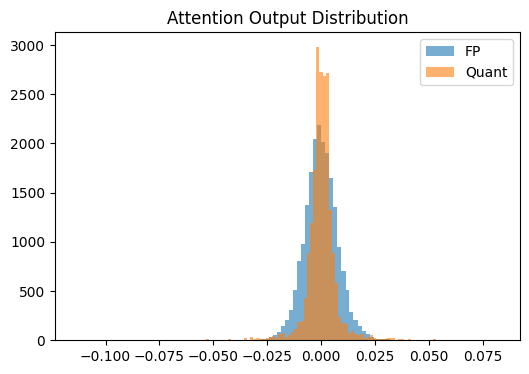

In [ ]:


plot_hist(debug["out_fp"], debug["out_q"], "Attention Output Distribution")


In [ ]:
import pandas as pd
import time

def compute_metrics(out_fp, out_q, loss_func):
    diff = (out_fp - out_q).abs()
    mae = diff.mean().item()
    mse = (diff**2).mean().item()
    # Perplexity (Layer-local approximation)
    # We treat the layer output as a probability distribution proxy
    ppl = torch.exp(loss_func(out_q.float(), out_fp.float())).item()
    cos_sim = torch.nn.functional.cosine_similarity(out_fp.flatten(), out_q.flatten(), dim=0).item()
    return mae, mse, ppl, cos_sim

results = []
bit_widths = [8, 4, 2]
loss_func = nn.MSELoss()

# Baseline (No Quantization)
results.append({
    "Bits": "FP16 (16)",
    "MAE": 0.0,
    "MSE": 0.0,
    "PPL (Approx)": 1.0,
    "Cosine Sim": 1.0,
    "Memory (MB)": layer_memory_mb(fp_attn)
})

for b in bit_widths:
    # 1. Initialize Quantized Layer
    q_attn = QuantLlamaAttention(fp_attn).to(next(model.parameters()).device)

    # Applying bit-width to all sub-modules
    for m in q_attn.modules():
        if isinstance(m, (QuantLinear, QuantMatMul)):
            m.n_bits = b

    # 2. Forward Pass
    with torch.no_grad():
         hidden = model.model.embed_tokens(inputs.input_ids)
         B, T, C = hidden.shape
         position_ids = torch.arange(T, device=hidden.device).unsqueeze(0)
         cos,sin=model.model.rotary_emb(hidden,position_ids)

         out_fp, _ = fp_attn(
              hidden_states=hidden,
              position_embeddings=(cos, sin),
              attention_mask=None,
          )
         out_q = q_attn(hidden, attention_mask=None, position_embeddings=(cos,sin),)

    # 3. Metrics
    mae, mse, ppl, cos_sim = compute_metrics(out_fp, out_q, loss_func)

    # Calculate Memory
    mem_mb = layer_memory_mb(fp_attn) * (b / 16.0)

    results.append({
        "Bits": f"INT{b}",
        "MAE": f"{mae:.6f}",
        "MSE": f"{mse:.6e}",
        "PPL (Approx)": f"{ppl:.4f}",
        "Cosine Sim": f"{cos_sim:.6f}",
        "Memory (MB)": f"{mem_mb:.2f}"
    })


df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

     Bits      MAE          MSE PPL (Approx) Cosine Sim Memory (MB)
FP16 (16)      0.0          0.0          1.0        1.0       128.0
     INT8 0.004021 3.534555e-05       1.0000   0.684082       64.00
     INT4 0.004822 4.369020e-05       1.0000   0.640625       32.00
     INT2 0.022797 6.155968e-04       1.0006   0.266846       16.00


##Perplexity calculation by replaying a single layer

In [ ]:
from datasets import load_dataset
from tqdm import tqdm
import torch.nn as nn

dataset = load_dataset('wikitext', 'wikitext-2-raw-v1', split='test')
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")

class Evaluator:
    def __init__(self, dataset, tokenizer, device, n_samples=5):
        self.dataset = tokenizer(
            "\n\n".join(dataset["text"]),
            return_tensors="pt"
        ).input_ids.to(device)

        self.device = device
        self.n_samples = n_samples
        self.seq_len = 512

    @torch.no_grad()
    def evaluate(self, model):
        model.eval()
        nlls = []
        loss_fct = nn.CrossEntropyLoss()

        for i in tqdm(range(self.n_samples)):
            batch = self.dataset[:, i*self.seq_len:(i+1)*self.seq_len]

            outputs = model(batch)
            logits = outputs.logits

            shift_logits = logits[:, :-1, :]
            shift_labels = batch[:, 1:]

            loss = loss_fct(
                shift_logits.reshape(-1, shift_logits.size(-1)),
                shift_labels.reshape(-1)
            )

            nlls.append(loss * self.seq_len)

        ppl = torch.exp(torch.stack(nlls).sum() / (self.n_samples * self.seq_len))
        return ppl.item()

In [ ]:
# Backup original layer
original_layer = model.model.layers[0]

# Replace with quantized attention inside that layer
# quant_layer = model.model.layers[0]
# quant_layer.self_attn = QuantLlamaAttention(original_layer.self_attn).to(model.device)

# model.model.layers[0] = quant_layer


In [ ]:
model.model.layers[0] = original_layer
evaluator = Evaluator(dataset, tokenizer, model.device)
fp_ppl = evaluator.evaluate(model)


100%|██████████| 5/5 [00:01<00:00,  2.56it/s]


In [ ]:
# FP model
model.model.layers[0] = original_layer
evaluator = Evaluator(dataset, tokenizer, model.device)
fp_ppl = evaluator.evaluate(model)

# Quant model
model.model.layers[0].self_attn = QuantLlamaAttention(original_layer.self_attn).to(model.device)
quant_ppl = evaluator.evaluate(model)

print("FP PPL:", fp_ppl)
print("Quant PPL:", quant_ppl)


100%|██████████| 5/5 [00:01<00:00,  2.86it/s]


FP PPL: 6.84765625
Quant PPL: 52.09375


In [ ]:
del model
torch.cuda.empty_cache()

In [ ]:
import copy
original_layer = copy.deepcopy(model.model.layers[0])


In [ ]:
import pandas as pd

In [ ]:
results = []
bit_widths = [8,4, 2]
loss_func = nn.MSELoss()

# Baseline (No Quantization)
results.append({
    "Bits": "FP16 (16)",
    "PPL": fp_ppl,
    "Memory (MB)":128
})

for b in bit_widths:
    # 1. Initialize Quantized Layer
    # FP model


      # Quant model
    model.model.layers[0]=copy.deepcopy(original_layer)
    q_layer = QuantLlamaAttention(model.model.layers[0].self_attn).to(model.device)



    # Apply bit-width to all sub-modules
    for m in q_layer.modules():
        if isinstance(m, (QuantLinear, QuantMatMul)):
            m.n_bits = b
    model.model.layers[0].self_attn = q_layer
    quant_ppl = evaluator.evaluate(model)
    for name, m in model.model.layers[0].self_attn.named_modules():
        if hasattr(m, "n_bits"):
            print(name, m.n_bits)

    print(quant_ppl)
    # 2. Forward Pass
    mem_mb = layer_memory_mb(original_layer.self_attn)*(b/16)
    results.append({
        "Bits": f"INT{b}",

        "PPL": f"{quant_ppl:.4f}",

        "Memory (MB)": f"{mem_mb:.2f}"
    })

# Display as Table
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

100%|██████████| 5/5 [00:01<00:00,  2.71it/s]


q_proj 8
k_proj 8
v_proj 8
o_proj 8
52.09375


100%|██████████| 5/5 [00:01<00:00,  2.70it/s]


q_proj 4
k_proj 4
v_proj 4
o_proj 4
52.09375


100%|██████████| 5/5 [00:01<00:00,  2.68it/s]


q_proj 2
k_proj 2
v_proj 2
o_proj 2
52.09375
     Bits       PPL Memory (MB)
FP16 (16)  6.847656         128
     INT8   52.0938       64.00
     INT4   52.0938       32.00
     INT2   52.0938       16.00
